# Learning Objectives

- Learn the concept for k-armed bandit problem statement
- Understand the Exploration vs Exploitation tradeoff
- Know stationary and non-stationary reward
- Recognize the various approach to solve k-armed bandit problems
  - Simple Average Q-value estimation
  - Incremental Implementation
  - Non-stationary environments
  - UCB action selection
  - Optimistic initial values



# Pre-requisites
+ Basic understanding of concept and terminoligies of Reinforcement Learning 


# Introduction

A multi or K-Armed bandit problem is known as a learner. Here, the learner takes some action and receive some reward value from the environment. The main goal of the learner is to find a policy that leads to maximum rewards. So, let's get started with what are bandit problems.

Consider a learning problem where we have to promote some advertisements for Coca-Cola repeatedly. Now, we want to test various types of advertisement for it. Our main goal is to select the ad that generates more clicks. 
Yeah! We don't know which ad will get more clicks. So, we need an algorithm to find the best advertisement. Thus, here comes k-armed bandits.

Before diving, let's see an analogy with one arm bandit or slot machine. Suppose we have a slot machine with one lever and display screen, as shown in Figure 1.

<figure>
<center>
<p>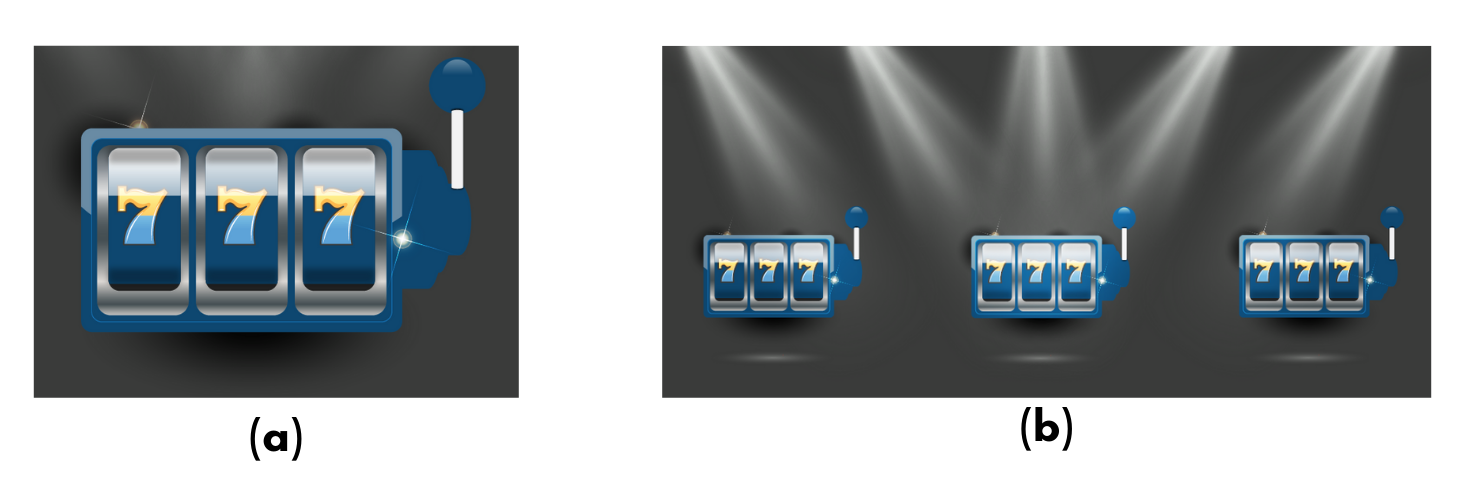</p>
</center>
</figure>



<center>
Figure 1: Slot-machine (a)Single-arm bandits Problem (b) Multi arm bandit Problem
</center>

The game is activated when we pull the lever. This single lever represents the single-arm or one-arm bandit. k-arm bandits represent k lever instead of one.

**What does bandit represent here?**

These machines(Slot machines) have a high probability of losing money / taking your money rather than winning or giving you back. Thus, known as Bandits.






# Exploration vs Exploitation Dilemma


The k-arm bandit problem works on the explore-exploit scenario. The trade-off between exploration and exploitation is one of the challenges in RL. Let's understand the exploration vs exploitation trade-off. The main goal in Reinforcement Learning is to maximize the expected total over some period of time. If we select certain actions **exploiting** only our current understanding of the actions and the rewards involved, we call such actions greedy actions and such process exploitation. But if we instead of going on only for the greedy action decide to explore some other unexplored actions, we call it **exploration**. Exploitation may maximize the expected reward on the current step but exploration may provide a greater total reward in long term.
 
<center>
   <figure>
<p>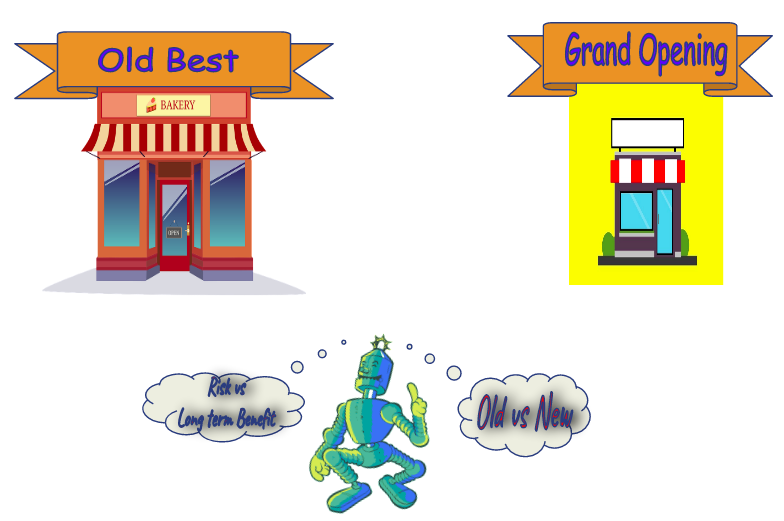</p>
       <figcaption align='center'> Figure 2: Exploration vs Exploitation trade-off</figcaption>
   </figure>
</center>
 
Suppose you are hungry and want a pizza. You order your pizza every time from a place that you know serves quite decent pizza and is worth all the money. And you have heard that there is a new restaurant in the town which specializes in Pizza. Now you are in dilemma. You can either get the pizza from the old place which you know you will enjoy as the pizza from the new place may not taste good anyway or you will get even tastier pizza if you order it from the new place. This situation is known as the exploration vs exploitation trade-off. This is the case of new vs old consequences. This is also the case of Risk vs Long term benefit where either you will only be risking by choosing a new place or get an even better place to order pizza from in the future.
 
So, what will you do? Will you choose your previous best or explore new ones? Taking the right decision is the main problem of reinforcement learning, where we can't do both exploration and exploitation at the same time. There is no best solution, but we always want to balance the exploration vs. exploitation trade-off, which maximizes our cumulative rewards.


# Stationary vs Non-Stationary

In the k-armed bandits problem, another important thing to remember is the distribution of the reward and how it changes over time in nonassociative settings (same state). There are two kinds of reward distribution:
- Stationary Rewards: Reward distribution remains the same irrespective of time steps
- Non-stationary Rewards: Reward distribution changes over time

> Note: Most of the RL problems are non stationary.


# A practical K-armed bandit problem

Let's see another analogy of a medical trial where a doctor wants to measure the effect of two different treatments. The doctor prescribes a medication at random and then monitors the patient's health. After a certain trial, the doctor notices the best-performing treatment.


<figure>
<center>
<p>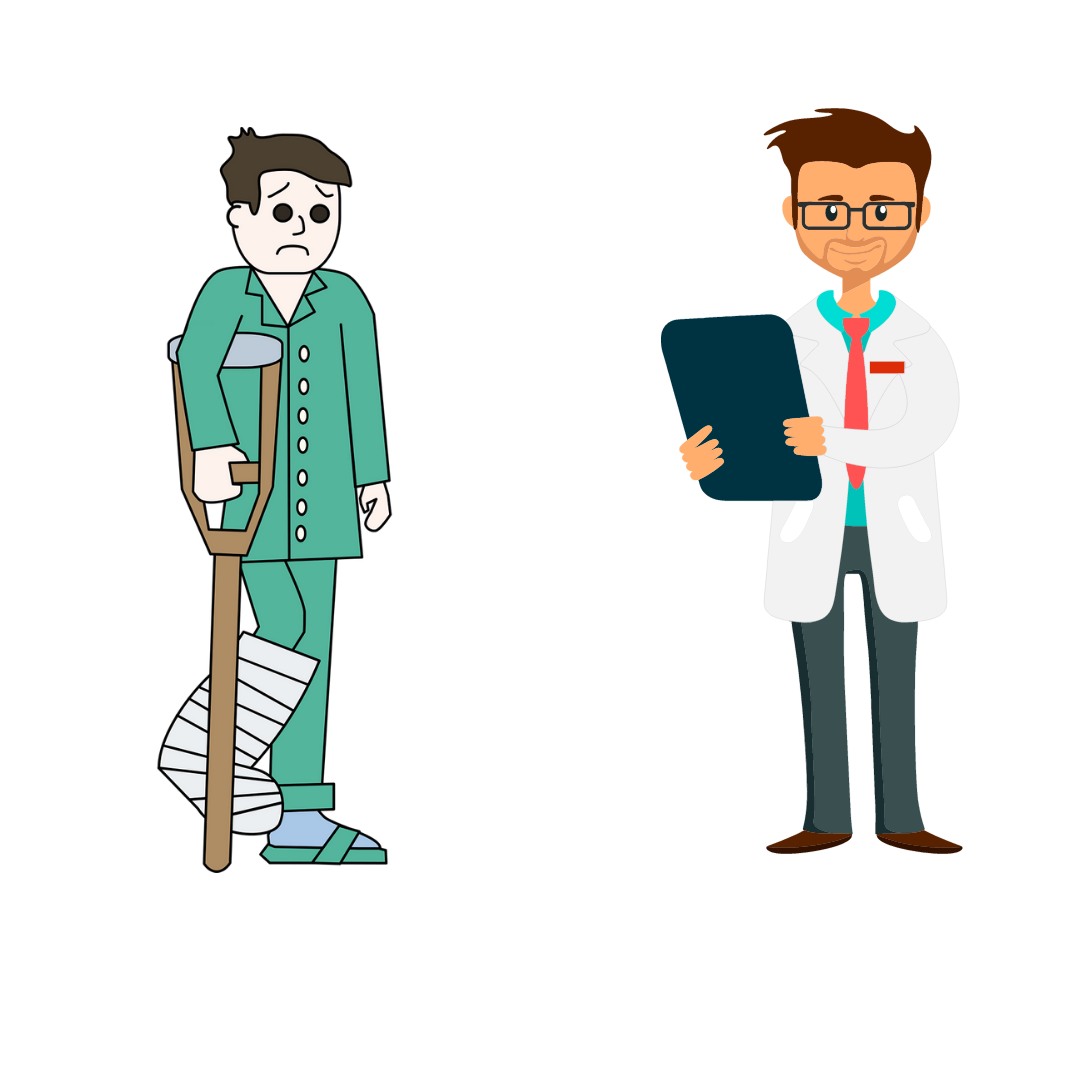</p>
</center>
</figure>
<center>
Figure 3: Patient and Doctor
</center>

This medical trial example is a case of the k-armed bandit problem.In the k-armed bandit problem, we have an agent or decision-maker,who choose the different actions and receives rewards.In the medical trial, a doctor plays the role of the agent. Action is choosing between two different treatments. Finally, the doctor receives the reward as the cure of the patient after the treatment.For each action, the doctor needs to define a value to decide the best action, also called the action-value function. 

In k-armed bandit, each of the k actions has an expected mean reward given that action selected, called value which is denoted by $q_*(a)$ and defined as:

$$q_*(a) \doteq \mathbb{E}[R_t | A_t=a]$$

Where $A_t$ is the action taken on timestep $t$ and corresponding reward is $R_t$. Here, we assume that we don't know the action values with certainity, although we may have estimates. Estimated value of the action $a$ at time step $t$ is $Q_t(a)$. We would prefer if $Q_t(a)$ to be close to $q_*(a)$.

Hence, the main idea of k-armed bandit problem is to maximize the rewards over the fixed time period. 


# Solving K-armed bandit problems

It's a trivial case to choose the appropriate treatment. The doctors will run many trails to learn about the treatment. These are some methods to compute the value of each treatment in our medical trail example.


## 1. Simple Average Q-value estimation

This is a simple method of estimating the values of actions and using this estimation we can make action selection decision. It can be estimated by averaging the actually received rewards:

$$Q_t(a) \doteq \frac{\text{sum of rewards when } a \text{ taken prior to $t$}}{\text{no of times } a \text{ taken prior to $t$}}
\doteq \frac{\sum_{i=1}^{t-1} R_i. 1_{A_i=a}}{\sum_{i-1}^{t-1} 1_{A_i=a}}$$

$R_i$ is the reward at time-steps $i$, and $1_{predicate}$  denotes the random variable and will be one of the correct predicate result and 0 if false.
This method is also called a $sample-average$ method for estimating action values because each estimate averages the sample of relevant rewards. 

Let's go back to our medical trial example. A doctor must decide between the two possible treatments to prescribe. The doctor records a reward of one of the patients if get better else reward of zero 
Initially, the action value for both treatment is zero.
$$Q_0(treatment A) = 0 , Q_0(treatment B) = 0$$
Let's start with the first patient. The doctor gives treatment A and finds better. The doctor rewards one and updates the estimate of the value. 
$$Q_1(treatment A) = \frac{1}{1} = 1, Q_1(treatment B) = 0$$
The doctor again prescribes treatment A randomly to Second patient.It fails, the doctor records the reward as 0 and updates the estimate value.
$$Q_2(treatment A) = \frac{1+0}{2} = 0.5, Q_2(treatment B) = 0$$
Here the estimated value for treatment B remains 0 because we estimate zero initially.Suppose, these are the action value, after a certain trial of random selection,
$$Q_n(treatment A) = 0.16, Q_n(treatment B) = 0.5$$

Alright! After estimating the action value, we can take action selection decision in the following two ways:



* Greedy Action Selection:
It is the simplest selection rule which selects one of the actions with highest estimated value so called greedy action selection. If there are more than one greedy action, selection is made randomly, which is given by the following equation.
$$A_t \doteq argmax_a Q_i(a)$$
This action selection method always exploits the current knowledge to maximize the immediate reward which may reduce the long-term reward.

In the above example, if the doctor assign the treatment with the current best result i.e., $\mathbf{treatmentB = 0.5}$, then said to be greedy selection.
Alternatively, if the doctor choose to explore by choosing a non-greedy action then said to be epsilon -Greedy Action selection.The doctor would sacrifice immediate reward hoping to 
gain more information about the other actions. 



> Note: If reward variance = 0, this method knows the true value of each action after tying it once

* $\epsilon$ - Greedy Action Selection:
This method is different from above greedy action selection method. In this method, $\varepsilon$ gives the probability of selecting a random action. The value of $\varepsilon$ depends upon the type of problem upto what percentage we want to explore and exploit. Lesser the value of $\varepsilon$ may slow the reward process but in long run, it will give more cummulative rewards. The following diagram shows the comparisons.
<center>
<p>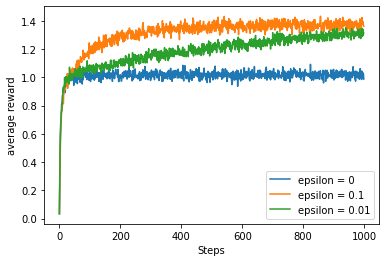</p>
</center>

<center>
Figure 4: Comparison between greedy and $\epsilon$ - greedy methods
</center>

<p>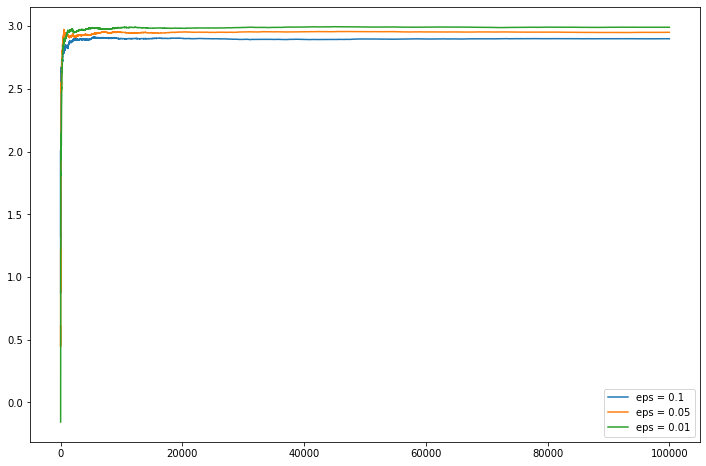</p>

<!-- **Note: While solving k-arm bandits problems, We need to select the action with highest value not only a value.** -->


## 2. Incremental Implementation
The action-value selection methods, as described above, estimate the action values as sample averages of average rewards. However, the question has arisen how these averages can be computed in a computationally efficient manner. So, incremental implementation helps to calculate this average efficiently.

Let $R_i$ now denote the reward received after the $i_{th}$ selection of this action, and let $Q_n$ mean the estimate of its action value after it has been selected $n-1$ times, which we can now write simply as

$$Q_n =\frac{R_1 +R_2 +···+R_{n-1}}{n-1}$$

Calculating $Q_n$ from above equation is not a good approach as memory and computational requirements will grow over time as more rewards are seen. Hence, we can use incremental implementation and can be computed by,

$$ Q_{n + 1} = \frac{1} {n} \sum _{i = 1}^{n} R_i$$

$$\hspace{6.2cm} = \frac{1} {n} (R_n + (n - 1) \frac{1} {(n-1)} \sum_{i = 1} ^{n-1} R_i )$$

$$\hspace{3.5cm} = \frac{1}{n} (R_n + (n - 1) Q_n)$$

$$\hspace{3.6cm} = \frac{1}{n} (R_n + n.Q_n  - Q_n)$$

$$\hspace{1.8cm} Q_{n+1} = Q_n + \frac{1} {n} (R_n - Q_n)$$

This implementation only requires memory for $Q_n$, $n$, and very small computation for each new rewards. Therefore, this saves memory and an efficient approach to evaluate the action value methods. The general update rule can be given as,

$\text{New Estimate = Old Estimate + Step Size[Target - Old Estimate]}$

The expression $[\text{Target} - \text{Old Estimate}]$ is an error in the estimation and it can be reduced by taking a step towards the final value, i.e. $\text{Target}$.


## 3. Solving non-stationary environments

As far as we discussed, the averaging methods for the stationary bandit problems where reward probability doesn't change over time. However, we often face reinforcement learning problems which are non-stationary. For this kind of problem, it is good to give more weight to recent rewards than long-past rewards. Hence, we introduce a discounting factor to give less weight to long-term rewards. Now, the incremental equation becomes,

$$ Q_{n+1} \doteq Q_n + \alpha[R_n - Q_n]$$

where the step size parameter, $\alpha\epsilon$ (0, 1].

$$Q_{n+1} = \alpha R_n + (1 - \alpha) Q_n$$

$$\hspace{5.7cm} = \alpha R_n + (1 - \alpha) [\alpha R_{n-1} + (1 - \alpha) Q_{n-1}]$$

$$\hspace{5.7cm} = \alpha R_n + (1 - \alpha) \alpha R_{n-1} + (1 - \alpha)^2 Q_{n-1}]$$

Further solving above equation gives,

$$\hspace{3cm}Q_{n+1} = (1 - \alpha)^nQ_1 + \sum_{i = 1}^{n} \alpha (1 - \alpha)^{n-i} R_i$$

where $Q_1$ is the initial estimation. Since, $(1 - \alpha) < 0$, the weight given to $R_i$ decreases as intervening rewards increases exponentially i.e., $(1 - \alpha)^{n-i}$. Therefore, sometimes, this method is also called an $exponential\space recency-weighted\space average.$



## Solving Exploration problems


### Upper-Confidence-Bound Action Selections

One of the way to balancing the exploration and exploitation problem is Upper-Confidence-Bound(UCB) action selection. Exploration needs to be done because of uncertainty about the action-value estimates. The $\varepsilon$ greedy selection performs better than greedy selection; however, it is not the best one. It has no preferences among the non-greedy action; it just randomly selects one of them. So, selecting among the non-greedy actions with respect to their potential to be actually optimal would be a better choice. Hence, UCB does the same with the following relation.

$$A_t \doteq \text{argmax} [Q_t(a) + c\sqrt{\frac{ln(t)}{N_t(a)}}]$$

where $c$ controls the degree of exploration and $N_t(a)$ denotes number of times action $a$ has selected prior to $t$. The main idea of this (UCB) method is that the square-root term, $\sqrt {\frac{ln(t)}{N_t(a)}}$ measures uncertainty or variance  in the estimate  of a's value and $c$ determine the confidence level. At each time, action $a$ is selected $N_t(a)$ increases, i.e., denominator term increases, so uncertainty term decreases, and we can call this scenario as exploiting our previous knowledge. On the other hand, new actions at every timestep increase $t$, which further increases $ln(t)$ value i.e., numerator term increase, so uncertainty term increase, and we can say this scenario as exploring new possible actions. In this way, UCB helps to balance the exploitation vs. exploration dilemma.
<center>
<p>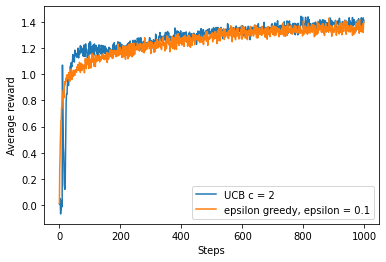</p>
<center>
  Figure 5: Comparision of UCB vs $\epsilon$-greedy method
</center>


## 5. Optimistic Initial Values

All the methods we have discussed are somehow dependent on initial action-value estimates, $Q_t(a)$. Therefore, it is good to approach to initialize $Q_t(a)$ to some value. This encourages exploration somehow. This method is called $biased$ in the language of statistics.

At a glance, until now, we initialize $Q(a)$ value to zero; however, if we become more optimistic and initialize some values, then our model does better for stationary problems. It is better to initialize values optimistically in the beginning. However, there is some limitation of this method which are given below:

* Explores only early time not later
* Not suited for non-stationary problems
* In practice, we may not know how to initialize value optimistically
<center>
<p>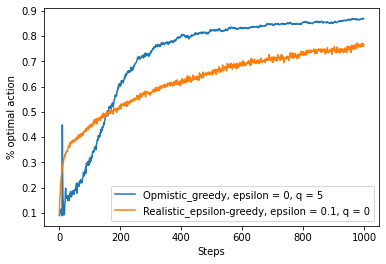</p>
<center>
Figure 6: Effect of optimistic initial action-values
</center>


# Key Takeaways
- A multi or K-Armed bandit problem is known as a learner. Here, the learner takes some action and receive some reward value from the environment. 

- The main goal of the learner is to find a policy that leads to maximum rewards.

- Exploration vs. Exploitation

  - Exploit: The agent has to exploit what it already knows

  - Explore: The agent has to explore to get better rewards in the future.

- Reward distribution

  - Stationary Rewards: Reward distribution remains the same irrespective of time steps
  
  - Non-stationary Rewards: Reward distribution changes over time

- Most of the RL problems are non-stationary.


- Greedy action selection is the most straightforward selection rule that selects one of the highest estimated value actions.

- $ \epsilon $-greedy selection gives the probability of choosing a random action that depends on the type of problem we are solving.

- UCB Selection is one of the ways of balancing exploration and exploitation problems.

- Optimistic Initial Values encourages exploration.




# References

* Books
   * Richard S. Sutton and Andrew G. Barto, Reinforcement Learning, 2nd edition

       * Check unit 2, page 25 to understand k-armed bandit problem in more detail.

       * Check unit 2, page 35 to understand Upper Confidence Bound action selection in more detail.
